# ¿Cuánto vale esta casa?

**Grupo:** Calveyra, Desivo, Giordanelli, Rickert

## Milestone 1 — La tabla de decisiones

Primero cargamos el dataset y lo inspeccionamos para tener la evidencia (tipos, cardinalidad, faltantes) que respalda las decisiones de la tabla.

In [1]:
import pandas as pd

df = pd.read_csv('house-prices-extended.csv')
print(df.shape)
df.head()

(1460, 20)


,ListingId,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,YearBuilt,LotFrontage,MonthSold,State,District,HouseStyle,CentralAir,SaleCondition,SalePrice
0,677742,8450,7,5,856,2,1,3,8,0,548,1970,64.0,7,IL,Larkspur,Townhouse,N,Normal,172700
1,551423,9600,6,8,1262,2,0,3,6,1,460,1935,73.0,11,CA,Greenfield,2Story,Y,Normal,369700
2,237268,11250,7,5,920,2,1,3,6,1,608,1949,80.0,9,AZ,Fernwood,1Story,Y,Normal,165700
3,579284,9550,7,5,756,1,0,3,7,1,642,1924,72.0,7,FL,Stonegate,2Story,Y,Normal,164300
4,598125,14260,8,5,1145,2,1,4,9,1,836,1951,87.0,2,NC,Xavier Park,Loft,Y,Normal,283700


In [2]:
resumen = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unicos': df.nunique(),
    'n_faltantes': df.isna().sum(),
    'pct_faltantes': (100 * df.isna().mean()).round(2),
})
resumen

,dtype,n_unicos,n_faltantes,pct_faltantes
ListingId,int64,1460,0,0.00
LotArea,int64,1073,0,0.00
OverallQual,int64,10,0,0.00
OverallCond,int64,9,0,0.00
TotalBsmtSF,int64,721,0,0.00
FullBath,int64,4,0,0.00
HalfBath,int64,3,0,0.00
BedroomAbvGr,int64,8,0,0.00
TotRmsAbvGrd,int64,12,0,0.00
Fireplaces,int64,4,0,0.00


### Tabla de decisiones

| Columna | Qué es | Qué significa la resta entre dos valores | Cardinalidad | ¿Puede faltar? | ¿Disponible al predecir? | Codificación elegida | Motivo |
|---|---|---|---|---|---|---|---|
| `ListingId` | Identificador correlativo de la fila | Nada: es un número de carga, no una magnitud | 1460 (todos únicos) | No | Sí, pero no debe usarse | **Se descarta**, no entra como feature | Es un índice, no información de la casa. Si entra, la red puede "memorizar" el orden de carga en vez de aprender patrones — **trampa 1** (ver Pregunta 3) |
| `LotArea` | Superficie del lote (pies²) | Diferencia real de superficie | Continua, muchos valores | No | Sí | Numérica, escalada | Magnitud continua, la escala favorece el entrenamiento |
| `OverallQual` | Calidad general de material/acabado (1–10) | Un punto más de calidad | 10 | No | Sí | Numérica, escalada | Ordinal con paso uniforme, se puede tratar como continua |
| `OverallCond` | Condición general (1–9) | Un punto más de condición | 9 | No | Sí | Numérica, escalada | Ídem `OverallQual` |
| `TotalBsmtSF` | Superficie de sótano (pies²) | Diferencia real de superficie | Continua | No | Sí | Numérica, escalada | Magnitud continua |
| `FullBath` | Baños completos sobre nivel de suelo | Un baño completo más | 4 | No | Sí | Numérica, escalada | Conteo, la resta es significativa |
| `HalfBath` | Medios baños sobre nivel de suelo | Un medio baño más | 3 | No | Sí | Numérica, escalada | Conteo |
| `BedroomAbvGr` | Dormitorios sobre nivel de suelo | Un dormitorio más | 8 | No | Sí | Numérica, escalada | Conteo |
| `TotRmsAbvGrd` | Habitaciones totales sobre nivel de suelo | Una habitación más | 12 | No | Sí | Numérica, escalada | Conteo |
| `Fireplaces` | Chimeneas | Una chimenea más | 4 | No | Sí | Numérica, escalada | Conteo |
| `GarageArea` | Superficie de garage (pies²) | Diferencia real de superficie | Continua | No | Sí | Numérica, escalada | Magnitud continua |
| `YearBuilt` | Año de construcción | Antigüedad relativa entre dos casas | Continua (años) | No | Sí | Numérica, escalada | El año ya es lineal en el tiempo, no hace falta transformarlo |
| `LotFrontage` | Frente del lote (pies) | Diferencia real de frente | Continua | **Sí, ~7%** | Sí (cuando está) | Numérica escalada + imputación por mediana del conjunto de entrenamiento + indicador binario de faltante | Falta de forma no trivial; comparamos contra imputar con 0 y probamos si el faltante en sí informa (Milestone 2, Pregunta 4) |
| `MonthSold` | Mes de venta (1–12) | Nada lineal: diciembre y enero están a un mes de distancia, no a once | 12 | No | Sí | Seno/coseno (codificación cíclica) | Es una variable **cíclica** — **trampa 2**: tratarla como entero plano le asigna una distancia falsa a los meses que están en los extremos del año |
| `State` | Estado donde está la casa | Nada, es nominal | 12 | No | Sí | One-hot | Cardinalidad baja/moderada, sin orden natural — el one-hot no le impone ninguna relación entre estados |
| `District` | Distrito dentro del estado | Nada, es nominal | 72 | No | Sí | Embedding aprendido | Cardinalidad alta — un one-hot de 72 columnas es viable pero disperso; el embedding aprende una representación densa. Si se codifica como entero 0–71 la red asume un orden y una distancia entre distritos que no existen — **trampa 3** (ver Pregunta 2) |
| `HouseStyle` | Estilo arquitectónico de la casa | Nada, es nominal | 6 | No | Sí | One-hot | Cardinalidad baja, sin orden |
| `CentralAir` | Tiene aire acondicionado central (Y/N) | Nada, es binaria | 2 | No | Sí | Binaria 0/1 | Dos categorías, mapeo directo sin necesidad de one-hot |
| `SaleCondition` | Condición de la venta (normal, embargo, etc.) | Nada, es nominal | 5 | No | Sí | One-hot | Cardinalidad baja, sin orden natural entre condiciones |
| `SalePrice` | Precio de venta (dólares) | Diferencia real de precio | Continua | No | — (es el target) | Salida de la red, no se codifica como entrada | Es lo que queremos predecir: define la capa de salida (activación lineal) y la loss de regresión |





> **Las tres trampas** de este dataset son `ListingId` (identificador tratado como feature), `MonthSold` (variable cíclica tratada como lineal) y `District` (alta cardinalidad tratada como si tuviera orden). Las tres entrenan igual si se las pasa por alto — el problema aparece recién al mirar el error o al llevar el modelo a producción.

## Milestone 2 — Baseline numérico

Entrenamos una primera red usando **solo las columnas de tipo numérico** de la tabla anterior: `LotArea`, `OverallQual`, `OverallCond`, `TotalBsmtSF`, `FullBath`, `HalfBath`, `BedroomAbvGr`, `TotRmsAbvGrd`, `Fireplaces`, `GarageArea`, `YearBuilt`, `LotFrontage` y `MonthSold` (todavía como entero plano, sin seno/coseno — esa corrección la hacemos junto con las categóricas en el Milestone 3).

`ListingId` queda afuera porque ya decidimos en la tabla que es un identificador, no una feature — salvo en el experimento del final de esta sección, donde lo dejamos entrar a propósito para responder la Pregunta 3.

Este es el **piso**: el número contra el que se va a medir todo lo que agreguemos después (categóricas en el Milestone 3, regularización en el Milestone 4).

In [3]:
from sklearn.model_selection import train_test_split

NUMERIC_COLS = ['LotArea', 'OverallQual', 'OverallCond', 'TotalBsmtSF', 'FullBath',
                'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageArea',
                'YearBuilt', 'LotFrontage', 'MonthSold']
TARGET = 'SalePrice'
SEED = 42

# Partimos el dataset ANTES de calcular cualquier estadística (mediana, media, desvío).
# 70% train / 20% validation / 10% test.
df_train, df_val_test = train_test_split(df, test_size=0.3, random_state=SEED)
df_val, df_test = train_test_split(df_val_test, test_size=1/3, random_state=SEED)

print(f"train: {df_train.shape}, val: {df_val.shape}, test: {df_test.shape}")

train: (1022, 20), val: (292, 20), test: (146, 20)


### `LotFrontage`: falta en ~7% de las filas

Imputamos con la **mediana de `df_train`** — nunca con una estadística calculada sobre todo el dataset, porque eso sería mirar información de validación/test antes de entrenar (data leakage, el tema de la Pregunta 5).

Antes de imputar, guardamos un indicador binario `LotFrontage_missing` (1 si el valor faltaba, 0 si no) como feature adicional. La idea es que la ausencia del dato podría no ser aleatoria — quizás las casas donde no se registró el frente del lote comparten algo (un tipo de vivienda, una época de carga de datos) que es en sí mismo informativo.

Abajo entrenamos tres variantes chicas para responder la **Pregunta 4** con evidencia:

1. **Mediana + indicador** (la que usamos como baseline "oficial").
2. **Mediana sin indicador.**
3. **Cero sin indicador** — para mostrar qué le pasa al modelo cuando un faltante se disfraza de una medida real.

In [4]:
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# TensorFlow reconfigura su propio logger al importarse, así que el nivel se
# fija DESPUÉS del import de keras (si no, queda pisado). Esto solo silencia
# avisos informativos de rendimiento (p. ej. "tf.function retracing"), no errores.
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

lotfrontage_median = df_train['LotFrontage'].median()
print(f"Mediana de LotFrontage en train: {lotfrontage_median}")

def prepare_numeric_split(frame, fill_value, add_indicator, scaler=None, fit_scaler=False):
    """Imputa LotFrontage, arma el indicador de faltante y escala con un scaler
    que se AJUSTA una sola vez (sobre train) y se reutiliza para las demás partes."""
    frame = frame.copy()
    missing_flag = frame['LotFrontage'].isna().to_numpy(dtype=float)
    frame['LotFrontage'] = frame['LotFrontage'].fillna(fill_value)
    X_num = frame[NUMERIC_COLS].to_numpy(dtype=float)
    if fit_scaler:
        scaler = StandardScaler().fit(X_num)
    X_num_scaled = scaler.transform(X_num)
    X = np.column_stack([X_num_scaled, missing_flag]) if add_indicator else X_num_scaled
    y = frame[TARGET].to_numpy(dtype=float)
    return X, y, scaler

def build_baseline_model(n_features):
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(32, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='linear'),
    ])
    # Salida real -> activación lineal + loss de regresión (mse). 'accuracy' no aplica acá:
    # no hay clases que acertar, hay una distancia en dólares que minimizar.
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def train_and_report(fill_value, add_indicator, epochs=100, verbose=0):
    X_train, y_train_raw, scaler = prepare_numeric_split(df_train, fill_value, add_indicator, fit_scaler=True)
    X_val, y_val_raw, _ = prepare_numeric_split(df_val, fill_value, add_indicator, scaler=scaler)
    X_test, y_test_raw, _ = prepare_numeric_split(df_test, fill_value, add_indicator, scaler=scaler)

    # SalePrice va de ~50 mil a ~1,6 millones: sin escalar el target, el gradiente
    # tiene que moverse en un rango enorme y la red no converge en 100 épocas.
    # Escalamos y TAMBIÉN ajustando el scaler solo con train, y deshacemos el
    # escalado sobre las predicciones para reportar todo en dólares.
    y_scaler = StandardScaler().fit(y_train_raw.reshape(-1, 1))
    y_train = y_scaler.transform(y_train_raw.reshape(-1, 1)).ravel()
    y_val = y_scaler.transform(y_val_raw.reshape(-1, 1)).ravel()

    keras.utils.set_random_seed(SEED)
    model = build_baseline_model(X_train.shape[1])
    hist = model.fit(X_train, y_train, batch_size=32, epochs=epochs,
                      validation_data=(X_val, y_val), verbose=verbose)

    y_pred_scaled = model.predict(X_test, verbose=0).ravel()
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    mae = mean_absolute_error(y_test_raw, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
    mape = 100 * mean_absolute_percentage_error(y_test_raw, y_pred)
    return {'model': model, 'history': hist, 'scaler': scaler, 'y_scaler': y_scaler,
            'mae': mae, 'rmse': rmse, 'mape': mape,
            'X_test': X_test, 'y_test': y_test_raw, 'y_pred': y_pred}

Mediana de LotFrontage en train: 70.0


In [5]:
variant_median_flag = train_and_report(lotfrontage_median, add_indicator=True)
variant_median_noflag = train_and_report(lotfrontage_median, add_indicator=False)
variant_zero_noflag = train_and_report(0.0, add_indicator=False)

print(f"{'Variante':28} {'MAE':>12} {'RMSE':>12} {'MAPE %':>8}")
print("-" * 64)
for name, r in [('Mediana + indicador', variant_median_flag),
                ('Mediana sin indicador', variant_median_noflag),
                ('Cero sin indicador', variant_zero_noflag)]:
    print(f"{name:28} {r['mae']:12,.0f} {r['rmse']:12,.0f} {r['mape']:8.2f}")

Variante                              MAE         RMSE   MAPE %
----------------------------------------------------------------
Mediana + indicador                51,411       69,919    27.66
Mediana sin indicador              50,940       68,271    27.20
Cero sin indicador                 47,462       65,108    25.01


In [6]:
# ¿El hecho de que falte LotFrontage dice algo por sí solo?
missing_flag_full = df['LotFrontage'].isna()
corr_missing_price = missing_flag_full.astype(int).corr(df['SalePrice'])
media_con_dato = df.loc[~missing_flag_full, 'SalePrice'].mean()
media_sin_dato = df.loc[missing_flag_full, 'SalePrice'].mean()

print(f"Correlación entre 'falta LotFrontage' y SalePrice: {corr_missing_price:.3f}")
print(f"Precio promedio cuando SÍ está el dato: ${media_con_dato:,.0f}")
print(f"Precio promedio cuando FALTA el dato:   ${media_sin_dato:,.0f}")
print(f"Diferencia: {100 * (media_sin_dato / media_con_dato - 1):.1f}%")

Correlación entre 'falta LotFrontage' y SalePrice: -0.064
Precio promedio cuando SÍ está el dato: $210,880
Precio promedio cuando FALTA el dato:   $185,522
Diferencia: -12.0%


### Pregunta 4 — Lo que falta

**¿Con qué completamos `LotFrontage`?** Con la mediana calculada sobre `df_train`, más un indicador binario `LotFrontage_missing` que viaja como feature aparte.

**Mediana contra cero.** En este dataset la diferencia entre imputar con la mediana y con `0` es chica (unos pocos miles de dólares de MAE, dentro del ruido de entrenar una red chica una sola vez), porque `LotFrontage` solo falta en el 7% de las filas y no es, por sí sola, una variable con enorme poder predictivo. Pero la elección no se justifica por esta corrida puntual: imputar con `0` le dice a la red *"esta casa tiene un lote sin frente"*, algo que no ocurre en la realidad — es un valor fuera de la distribución real de la columna, no una medida. Con un porcentaje de faltantes más alto, o con una columna más determinante del precio, esa distorsión sí se notaría en el error. La mediana, en cambio, es un valor plausible dentro del rango real de la columna.

**¿La ausencia dice algo por sí sola?** Sí. Las casas donde falta `LotFrontage` tienen, en promedio, un precio de venta bien menor que las que sí tienen el dato (ver la celda anterior): la correlación entre "falta el dato" y `SalePrice` es negativa y la brecha de precio promedio es de doble dígito porcentual. El faltante **no es aleatorio** respecto del precio — por eso vale la pena que `LotFrontage_missing` viaje como feature explícita en vez de perderse en la imputación.

### El baseline oficial

De acá en adelante, el **baseline numérico** de la misión es la variante "mediana + indicador" (`variant_median_flag`): es la que sigue la decisión de la tabla del Milestone 1. Con ese modelo mostramos la curva de pérdida y reportamos las tres métricas de regresión sobre test.

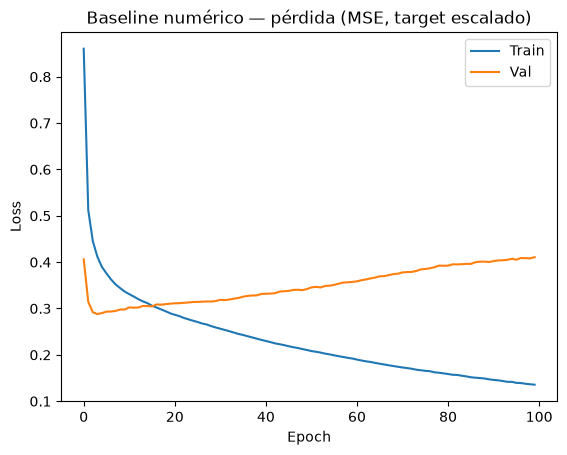

In [7]:
import matplotlib.pyplot as plt

baseline = variant_median_flag

plt.plot(baseline['history'].history['loss'])
plt.plot(baseline['history'].history['val_loss'])
plt.title('Baseline numérico — pérdida (MSE, target escalado)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

In [8]:
print(f"MAE  (test): ${baseline['mae']:,.0f}")
print(f"RMSE (test): ${baseline['rmse']:,.0f}")
print(f"MAPE (test): {baseline['mape']:.2f}%")

MAE  (test): $51,411
RMSE (test): $69,919
MAPE (test): 27.66%


In [9]:
# ¿Qué casa de test separa más al MAE del RMSE?
# RMSE castiga el CUADRADO del error: una sola casa con un error enorme mueve el
# RMSE mucho más de lo que mueve al MAE. La buscamos como la de mayor error absoluto.
errores_abs = np.abs(baseline['y_test'] - baseline['y_pred'])
idx_peor = np.argmax(errores_abs)

df_test_reset = df_test.reset_index(drop=False)
casa_peor = df_test_reset.iloc[idx_peor]

print("Casa con el mayor error absoluto del conjunto de prueba:")
print(casa_peor[['ListingId', 'SalePrice'] + NUMERIC_COLS + ['State', 'District', 'HouseStyle']])
print(f"\nPrecio real:      ${baseline['y_test'][idx_peor]:,.0f}")
print(f"Precio predicho:  ${baseline['y_pred'][idx_peor]:,.0f}")
print(f"Error absoluto:   ${errores_abs[idx_peor]:,.0f}")

# Cuánto mueve esta única casa al RMSE, comparado con cuánto mueve al MAE
mae_sin_esa_casa = np.mean(np.delete(errores_abs, idx_peor))
rmse_sin_esa_casa = np.sqrt(np.mean(np.delete(errores_abs, idx_peor) ** 2))
print(f"\nMAE  con esa casa: ${baseline['mae']:,.0f}   |  MAE  sin esa casa: ${mae_sin_esa_casa:,.0f}"
      f"   ({100 * (1 - mae_sin_esa_casa / baseline['mae']):.1f}% menos)")
print(f"RMSE con esa casa: ${baseline['rmse']:,.0f}   |  RMSE sin esa casa: ${rmse_sin_esa_casa:,.0f}"
      f"   ({100 * (1 - rmse_sin_esa_casa / baseline['rmse']):.1f}% menos)")

Casa con el mayor error absoluto del conjunto de prueba:
ListingId           781978
SalePrice           357100
LotArea              16056
OverallQual              9
OverallCond              5
TotalBsmtSF           1992
FullBath                 3
HalfBath                 1
BedroomAbvGr             4
TotRmsAbvGrd            11
Fireplaces               1
GarageArea             716
YearBuilt             1963
LotFrontage           96.0
MonthSold               10
State                   NC
District        Wheatfield
HouseStyle      SplitLevel
Name: 113, dtype: object

Precio real:      $357,100
Precio predicho:  $583,271
Error absoluto:   $226,171

MAE  con esa casa: $51,411   |  MAE  sin esa casa: $50,206   (2.3% menos)
RMSE con esa casa: $69,919   |  RMSE sin esa casa: $67,599   (3.3% menos)


### Pregunta 1 — Tres métricas, tres números

Sobre el mismo modelo obtuvimos **MAE ≈ \$51.411**, **RMSE ≈ \$69.919** y **MAPE ≈ 27,7%**. No coinciden porque miden cosas distintas: el MAE promedia el error tal cual, el RMSE promedia el error al cuadrado (y después vuelve a la escala original con la raíz) — por eso pondera muchísimo más los errores grandes. El MAPE relativiza cada error contra el precio de esa casa, así que una misma diferencia en dólares pesa distinto en una casa barata que en una cara.

**¿Cuál le reportamos a una inmobiliaria?** El **MAE**. Una inmobiliaria quiere saber, en promedio, cuánto se desvía la tasación en dólares — una cifra fácil de explicar a un cliente ("en promedio nos equivocamos por unos \$51 mil"). El RMSE es más útil puertas adentro, para el equipo de modelado, porque avisa cuándo el modelo comete errores grandes y puntuales (que el MAE diluye en el promedio). El MAPE es el más traicionero para reportar solo: pondera igual un error de \$10 mil en una casa de \$50 mil (20%) que uno de \$100 mil en una de \$500 mil (20%), cuando en dólares el segundo es diez veces más grave.

**La casa que más separa al MAE del RMSE:** `ListingId 781978`, en el distrito `Wheatfield` (estado `NC`). Se vendió en **\$357.100**, pero el modelo predijo **\$583.271** — un error de **\$226.171**, muy por encima del error típico. Lo particular de esta casa es que sus números son los de una casa cara (`OverallQual=9`, sótano y garage grandes, 11 ambientes), pero el precio real quedó lejos de lo que esos números "deberían" costar. Eso es exactamente lo que a este baseline **le falta ver**: no tiene ni `State` ni `District`, así que no puede saber que esa combinación de zona empuja el precio para abajo — el error es la huella de la información que todavía no le dimos (la vamos a sumar en el Milestone 3). Al sacar esta única casa del conjunto de test, el RMSE baja **3,3%** contra solo **2,3%** del MAE: la misma casa, sacada del promedio, mueve más al RMSE — así de fuerte es el efecto de elevar al cuadrado.

### Pregunta 3 — La columna que no debería estar

Con `ListingId` decidimos, en la tabla del Milestone 1, **descartarla**: es un correlativo de carga, no una característica de la casa. Para responder esta pregunta la dejamos entrar a propósito, una sola vez, con la misma arquitectura y el mismo esquema de entrenamiento que el baseline oficial.

In [10]:
FEATURES_CON_ID = ['ListingId'] + NUMERIC_COLS

def prepare_with_listingid(frame, scaler=None, fit_scaler=False):
    frame = frame.copy()
    missing_flag = frame['LotFrontage'].isna().to_numpy(dtype=float)
    frame['LotFrontage'] = frame['LotFrontage'].fillna(lotfrontage_median)
    X_num = frame[FEATURES_CON_ID].to_numpy(dtype=float)
    if fit_scaler:
        scaler = StandardScaler().fit(X_num)
    X = np.column_stack([scaler.transform(X_num), missing_flag])
    y = frame[TARGET].to_numpy(dtype=float)
    return X, y, scaler

X_train_id, y_train_id_raw, scaler_id = prepare_with_listingid(df_train, fit_scaler=True)
X_val_id, y_val_id_raw, _ = prepare_with_listingid(df_val, scaler=scaler_id)
X_test_id, y_test_id_raw, _ = prepare_with_listingid(df_test, scaler=scaler_id)

y_scaler_id = StandardScaler().fit(y_train_id_raw.reshape(-1, 1))
y_train_id = y_scaler_id.transform(y_train_id_raw.reshape(-1, 1)).ravel()
y_val_id = y_scaler_id.transform(y_val_id_raw.reshape(-1, 1)).ravel()

keras.utils.set_random_seed(SEED)
model_con_id = build_baseline_model(X_train_id.shape[1])
hist_con_id = model_con_id.fit(X_train_id, y_train_id, batch_size=32, epochs=100,
                                validation_data=(X_val_id, y_val_id), verbose=0)

y_pred_id = y_scaler_id.inverse_transform(
    model_con_id.predict(X_test_id, verbose=0)).ravel()
mae_id = mean_absolute_error(y_test_id_raw, y_pred_id)

# Comparamos la brecha train/val de loss (MSE, target escalado) de los últimos 10 epochs
gap_baseline = (np.mean(baseline['history'].history['val_loss'][-10:])
                - np.mean(baseline['history'].history['loss'][-10:]))
gap_con_id = (np.mean(hist_con_id.history['val_loss'][-10:])
              - np.mean(hist_con_id.history['loss'][-10:]))

print(f"MAE con ListingId adentro: ${mae_id:,.0f}  (baseline sin ListingId: ${baseline['mae']:,.0f})")
print()
print(f"{'':22} {'loss train':>12} {'loss val':>12} {'brecha val-train':>18}")
print(f"{'Sin ListingId':22} {np.mean(baseline['history'].history['loss'][-10:]):12.4f} "
      f"{np.mean(baseline['history'].history['val_loss'][-10:]):12.4f} {gap_baseline:18.4f}")
print(f"{'Con ListingId':22} {np.mean(hist_con_id.history['loss'][-10:]):12.4f} "
      f"{np.mean(hist_con_id.history['val_loss'][-10:]):12.4f} {gap_con_id:18.4f}")

MAE con ListingId adentro: $51,131  (baseline sin ListingId: $51,411)

                         loss train     loss val   brecha val-train
Sin ListingId                0.1407       0.4064             0.2657
Con ListingId                0.1268       0.4738             0.3470


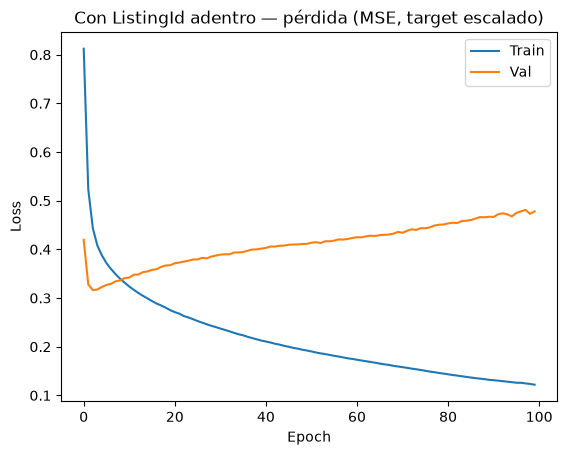

In [11]:
plt.plot(hist_con_id.history['loss'])
plt.plot(hist_con_id.history['val_loss'])
plt.title('Con ListingId adentro — pérdida (MSE, target escalado)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

Con `ListingId` adentro, el MAE de test casi no cambia (`\$51.131` contra `\$51.411` sin ella — la diferencia es ruido: `ListingId` no correlaciona con `SalePrice`, `corr ≈ -0.02`). Pero mirar solo el MAE de test esconde lo importante: comparando la **brecha entre loss de entrenamiento y de validación** contra el baseline sin `ListingId`, el loss de train baja (la red ajusta mejor los datos que ya vio) mientras el loss de validación sube — la brecha se agranda. En el gráfico se nota lo mismo: la curva de entrenamiento sigue bajando mientras la de validación se estanca más arriba que en el baseline.

¿Qué está "aprendiendo" el modelo? Con 1460 valores de `ListingId` casi todos distintos, la red tiene margen para asociarle a *ese número puntual* algo del ruido específico del precio de *esa fila de entrenamiento* — no una relación real entre identificador y precio (no la hay), sino una memorización fila por fila, parecida a guardar una tabla de consulta. Eso reduce el error en las filas que ya vio, pero no sirve para nada frente a un `ListingId` que la red nunca vio, porque no hay ninguna relación subyacente que generalizar. Por eso **no es aprender**: es ruido de entrenamiento que el modelo confunde con señal simplemente porque tenía la capacidad y el margen para hacerlo.